# testConditionalGANPytorch1  
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

AIM: create a simple GAN that is easy to test our basic framework

generate y = x^2

ref: 
- chapter 6. in Generative Advisarial Networks with Python  
    this does not work. Keras/tensor flow version issues?  
    re-write example using pytorch

- [pytorch doc](https://pytorch.org/docs/stable/index.html)

installed following to get rid of warning
```
https://ipywidgets.readthedocs.io/en/stable/user_install.html
conda install -c conda-forge jupyterlab_widgets
conda install -c conda-forge ipywidgets

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
```

In [1]:
import ipynbname
import matplotlib.pyplot as plt

from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
from numpy.random import rand
from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

from torch import nn
torch.manual_seed(0) # Set for testing purposes, please do not change!

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img


## Create models

In [2]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),
            nn.Linear(15, nOutputs),
        )
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

In [3]:
class ParabolaDiscriminator( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()

        # keras
        # model = Sequential()
    	# model.add(Dense(25, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    	# model.add(Dense(1, activation='sigmoid'))
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            nn.Linear(25, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)
        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='sigmoid')
        nn.init.zeros_(self.model[2].bias)

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaDiscriminator() :
    inputSize = 2
    discriminator = ParabolaDiscriminator( inputSize )
    numTest = 2
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaDiscriminator()


predictions :
tensor([[0.5380],
        [0.5828]], grad_fn=<SigmoidBackward0>)


## Data Utilities
function to generate real and fake tensors

In [4]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    X1 = rand(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 5 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([5, 2]) rank : 2 num elements : 10
tensor([[ 0.1294,  0.0168],
        [-0.2781,  0.0773],
        [ 0.3484,  0.1214],
        [-0.3073,  0.0945],
        [ 0.3254,  0.1059]])

y.device : cpu
y.shape: torch.Size([5, 1]) rank : 2 num elements : 5
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [5]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    xInput = randn(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[-0.5774,  0.7465, -1.3002, -1.1271, -1.4140],
        [ 1.4609,  0.7385,  0.1391,  0.4437,  0.3705],
        [ 0.9458,  0.6574, -0.2200,  0.5912,  1.5139]])
torch.Size([3, 5])


In [6]:
def generateFakeSamples(generator : ParabolaGenerator, 
                        latentDimensions : int,
                        n : int,
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor]:
    '''
    use the generator to generate n fake examples, with class labels

    gradient calculation is disabled. (should run faster)

    device. either 'cpu' or 'cuda', default 'cpu'


    returns (fakeSamples, fakeLabels)
        labels will be zeros.
    '''
    # generate points in latent space
    noiseVector = generateLatentPoints(latentDimensions, n)

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    # Disable gradient calculation for inference
    with torch.no_grad():
        fakeSamples = generator(noiseVector)
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return fakeSamples, fakeLabels

def testGenerateFakeSamples():
    latentDimensions = 5
    numOutputs = 2
    

    gen = ParabolaGenerator( latentDimensions, numOutputs )

    numSamples = 3
    fakeSamples, fakeLabels = generateFakeSamples( gen, latentDimensions, numSamples)

    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )
    print(f'fakeSamples.device : {str(fakeSamples.device)}')

    print( fakeSamples )

    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 


testGenerateFakeSamples()


fakeSamples.shape: torch.Size([3, 2]) rank : 2 num elements : 6
fakeSamples.device : cpu
tensor([[-0.8041,  0.8269],
        [ 1.8860,  0.0418],
        [ 2.3520, -0.3864]])

fakeLabels.shape: torch.Size([3, 1]) rank : 2 num elements : 3
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.]])


## Train Model

In [7]:
def getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
                         n, zDim, device) -> torch.Tensor:
    '''
    Return the loss of the discriminator on real and fake samples.
    
    Parameters:
        generator: the generator model, which returns an image given z-dimensional noise
        
        discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
        criterion: the loss function, which should be used to compare 
               the discriminator's predictions to the ground truth reality of the images 
               (e.g. fake = 0, real = 1)
               
        real: a batch of real samples
        
        n: the number of fakes the generator should produce, 
                which is also the length of the real images
                
        zDim: the dimension of the noise vector, a scalar
        
        device: the device type
        
    Returns:
        discriminatorLoss: a torch scalar loss value for the current batch
    '''
    # generate some fake samples
    fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, n, device )

    # get discriminator's prediction of the fake samples
    # forward
    predictionsOnFakes = discriminator( fakeSamples )
    
    # calculate the loss on fakes
    expected = torch.zeros(n, 1, device=device)  # All weights are equal to 0, ie fake
    discriminatorLossOnFake = criterion(predictionsOnFakes, expected) 
   
    # calculate loss on real samples
    predictionsOnReal = discriminator( realSamples )
    expected = torch.ones(n, 1, device=device)  # All weights are equal to 1, ie real
    discriminatorLossOnReal = criterion(predictionsOnReal, expected) 
   
    # calculate the average loss
    discriminatorLoss = (discriminatorLossOnReal + discriminatorLossOnFake) / 2
    
    return discriminatorLoss

In [8]:
def testGetDiscriminatorLossSample() :
    zDim = 5 # length of noise vector
    exampleLength = 2 # X,Y
    device = 'cpu'
    batchSize = 4

    generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
    discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
    criterion = nn.BCEWithLogitsLoss()

    realSamples, realLabels = generateRealSamples( batchSize, device )
    
    discriminatorLoss = getDiscriminatorLoss(generator, discriminator, criterion, 
                                             realSamples, batchSize,
                                              zDim, device)

    print( f'discriminator loss : {discriminatorLoss}') 

testGetDiscriminatorLossSample()

discriminator loss : 0.6952188611030579


In [9]:
def getGeneratorLoss(generator, discriminator, criterion, 
                     n, zDim, device) -> torch.Tensor:
    '''
    The generator never sees real samples. Loss is
    calculated only on fake samples

        Parameters:
        generator: the generator model, which returns an image given z-dimensional noise
        
        discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
        criterion: the loss function, which should be used to compare 
               the discriminator's predictions to the ground truth reality of the images 
               (e.g. fake = 0, real = 1)
               
        n: the number of fakes the generator should produce, 
                
        zDim: the dimension of the noise vector, a scalar
        
        device: the device type
        
    Returns:
        generatorLoss: a torch scalar loss value for the current batch
    '''
    noiseVector = generateLatentPoints(zDim, n, device)

    # forward() is the old way of doing things it breaks the grader
    #fakeImgs = gen.forward(noiseVector)
    fakeSamples = generator(noiseVector)
    
    # forward() is the old way of doing things     
    # predictionsOnFake = disc.forward( fakeImgs ).detach()
    predictionsOnFake = discriminator( fakeSamples )#.detach()
    
    # we are trying to trick the discriminator into thinking
    # the fakes are real
    expected = torch.ones(n, 1, device=device)  
    generatorLoss = criterion(predictionsOnFake, expected) 
    #     print(f'\nAEDWIP type(generatorLoss): {type(generatorLoss)}')
    #     print(f'AEDWIP generatorLoss.shape: {generatorLoss.shape}')
    #     print(f'AEDWIP generatorLoss: {generatorLoss}')   

    return generatorLoss

In [10]:
def testGetGeneratorLoss():
    zDim = 5 # length of noise vector
    n = 4 # number of fakes to generate  
    exampleLength = 2 # X,Y
    device = 'cpu'    
    
    generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
    discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device)     
    criterion = nn.BCEWithLogitsLoss()

    generatorLoss = getGeneratorLoss(generator, discriminator, criterion, n, zDim, device) 
    print(f'generatorLoss.shape : {generatorLoss.shape}')
    print(f'generatorLoss\n{generatorLoss}')
    
testGetGeneratorLoss()    

generatorLoss.shape : torch.Size([])
generatorLoss
0.48100218176841736


In [11]:
# def summarizePerformance(epoch, generator, discriminator, latentDim, n=100):
def summarizePerformance( generator : ParabolaGenerator, 
                         latentDimensions : int,
                         outDir : str,
                        title : str):
    n = 100
    realSamples, realLabels = generateRealSamples( n )
    fakeSamples, fakeLabels = generateFakeSamples( generator, latentDimensions, n)
    
    #    # evaluate discriminator on real examples
    # _, acc_real = discriminator.evaluate(xReal, yReal)
    # # prepare fake examples
    # x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # # evaluate discriminator on fake examples
    # _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # # summarize discriminator performance
    # print(epoch, acc_real, acc_fake)
    # scatter plot real and fake data points
    
    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red')
    plt.scatter(fakeSamples[:, 0], fakeSamples[:, 1], color='blue')

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

In [12]:
# Set your parameters
criterion = nn.BCEWithLogitsLoss()
nEpochs = 500 #200
numBatchs = 200 #100 #50 # number of batchs per epoch
zDim = 5 # length of noise vector
displayStep = 500 #200 # 500
batchSize = 128
lr = 0.00001
exampleLength = 2 # X,Y
#device = 'cuda'
device = 'cpu'
plotStep = 2000 

generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam(generator.parameters(), lr=lr)

discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
discriminatorOptimizer = torch.optim.Adam(discriminator.parameters(), lr=lr)

Step 500: Generator loss: 0.7464033170938488, discriminator loss: 0.4533798633217815
Memory usage (RSS): 343.9375 MB
Step 1000: Generator loss: 1.4863481619358054, discriminator loss: 0.9120771656632433
Memory usage (RSS): 343.9375 MB
Step 1500: Generator loss: 2.2209875707626323, discriminator loss: 1.3771990720629719
Memory usage (RSS): 343.94140625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch010.png


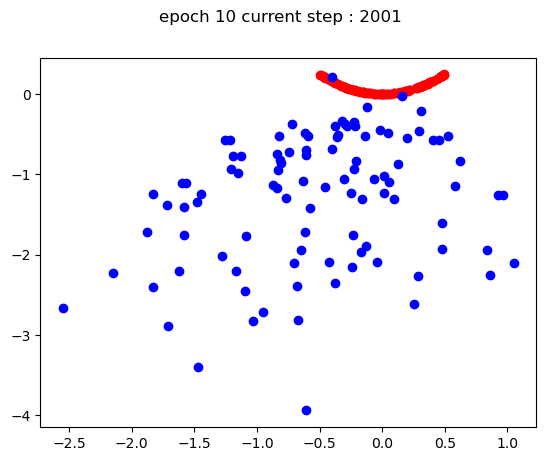

Step 2000: Generator loss: 2.950187496423713, discriminator loss: 1.8490580374002488
Memory usage (RSS): 351.3359375 MB
Step 2500: Generator loss: 3.6738531568050337, discriminator loss: 2.3277291699647877
Memory usage (RSS): 351.3359375 MB
Step 3000: Generator loss: 4.392051013469696, discriminator loss: 2.813360397279263
Memory usage (RSS): 351.35546875 MB
Step 3500: Generator loss: 5.104488384246832, discriminator loss: 3.306677732765672
Memory usage (RSS): 351.54296875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch020.png


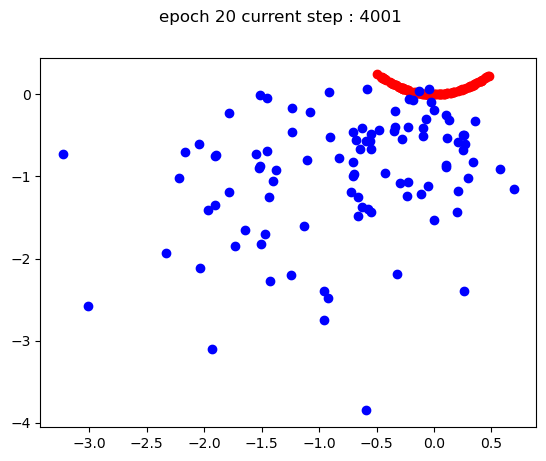

Step 4000: Generator loss: 5.811230276584629, discriminator loss: 3.807544566571711
Memory usage (RSS): 351.953125 MB
Step 4500: Generator loss: 6.512501017212868, discriminator loss: 4.31609192997217
Memory usage (RSS): 351.953125 MB
Step 5000: Generator loss: 7.208964312553408, discriminator loss: 4.8320454760193785
Memory usage (RSS): 351.953125 MB
Step 5500: Generator loss: 7.901231622815127, discriminator loss: 5.354359741747368
Memory usage (RSS): 351.953125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch030.png


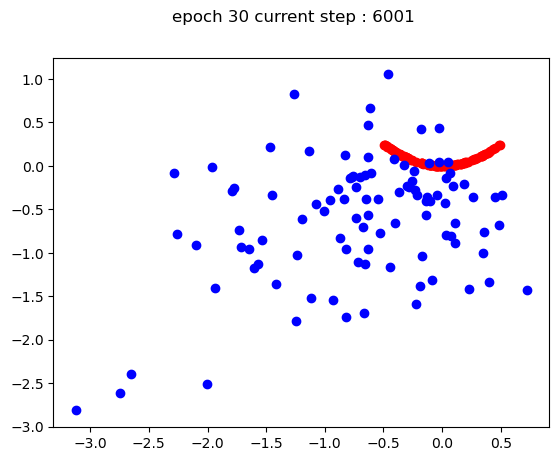

Step 6000: Generator loss: 8.590294266581541, discriminator loss: 5.882064350306978
Memory usage (RSS): 353.515625 MB
Step 6500: Generator loss: 9.277024209976219, discriminator loss: 6.413608443438991
Memory usage (RSS): 353.515625 MB
Step 7000: Generator loss: 9.96211574470999, discriminator loss: 6.947852058351016
Memory usage (RSS): 353.51953125 MB
Step 7500: Generator loss: 10.64705455255512, discriminator loss: 7.4837167059778995
Memory usage (RSS): 353.51953125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch040.png


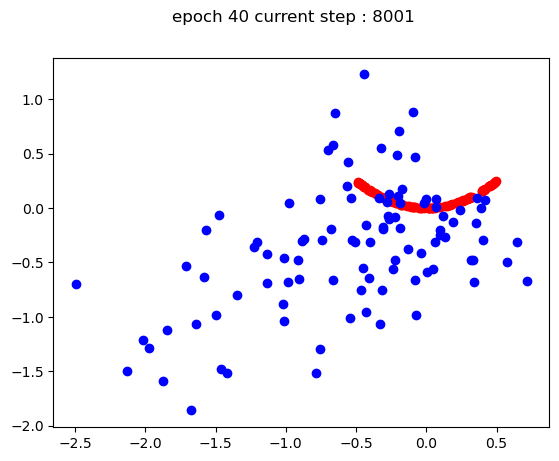

Step 8000: Generator loss: 11.332183407425912, discriminator loss: 8.02020757931469
Memory usage (RSS): 353.72265625 MB
Step 8500: Generator loss: 12.01836348891262, discriminator loss: 8.556672357380384
Memory usage (RSS): 353.72265625 MB
Step 9000: Generator loss: 12.705932562947304, discriminator loss: 9.092467694818987
Memory usage (RSS): 353.72265625 MB
Step 9500: Generator loss: 13.395475048303624, discriminator loss: 9.627463097751145
Memory usage (RSS): 353.72265625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch050.png


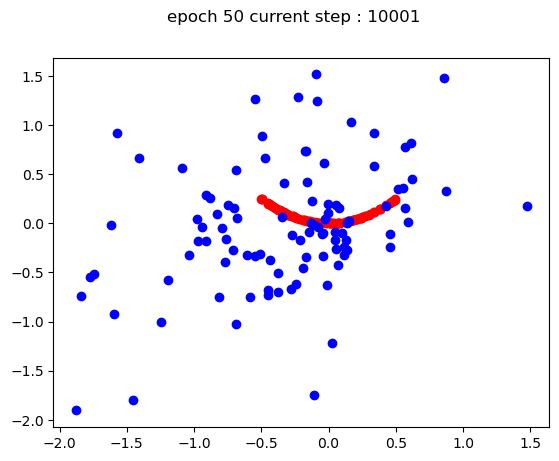

Step 10000: Generator loss: 14.086828907966622, discriminator loss: 10.161084495604053
Memory usage (RSS): 355.28125 MB
Step 10500: Generator loss: 14.780145135283473, discriminator loss: 10.693709415137768
Memory usage (RSS): 355.4375 MB
Step 11000: Generator loss: 15.475528107881553, discriminator loss: 11.225694647848623
Memory usage (RSS): 355.4375 MB
Step 11500: Generator loss: 16.17259475862978, discriminator loss: 11.75616258090735
Memory usage (RSS): 355.50390625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch060.png


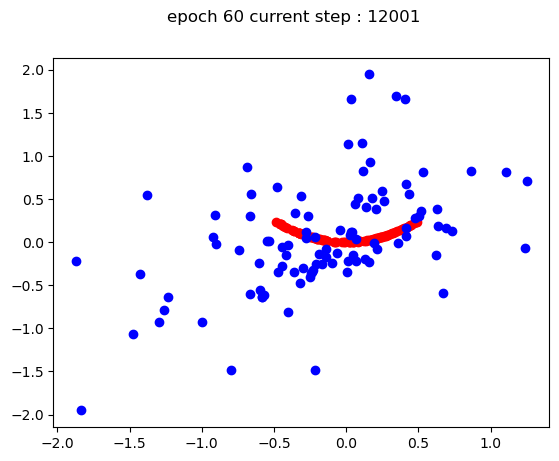

Step 12000: Generator loss: 16.87166435706611, discriminator loss: 12.286178486049192
Memory usage (RSS): 355.64453125 MB
Step 12500: Generator loss: 17.571959806442237, discriminator loss: 12.81577637964487
Memory usage (RSS): 355.64453125 MB
Step 13000: Generator loss: 18.27365232253072, discriminator loss: 13.344919223725801
Memory usage (RSS): 355.64453125 MB
Step 13500: Generator loss: 18.976384679198215, discriminator loss: 13.874062220275396
Memory usage (RSS): 355.64453125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch070.png


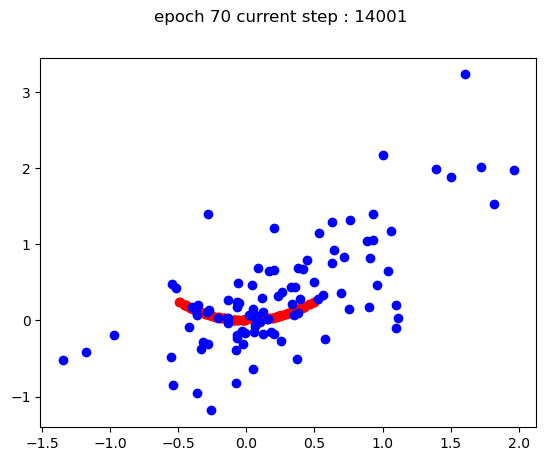

Step 14000: Generator loss: 19.679655479192697, discriminator loss: 14.402984653651707
Memory usage (RSS): 357.2109375 MB
Step 14500: Generator loss: 20.383410395502995, discriminator loss: 14.933130264937864
Memory usage (RSS): 357.2109375 MB
Step 15000: Generator loss: 21.087251739621095, discriminator loss: 15.464100018560881
Memory usage (RSS): 357.234375 MB
Step 15500: Generator loss: 21.79106192910662, discriminator loss: 15.995961191475377
Memory usage (RSS): 357.234375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch080.png


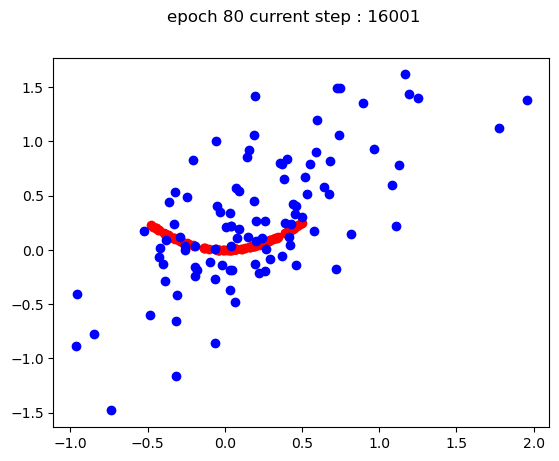

Step 16000: Generator loss: 22.49469761478894, discriminator loss: 16.52931368845699
Memory usage (RSS): 357.79296875 MB
Step 16500: Generator loss: 23.197835676073954, discriminator loss: 17.06410093909499
Memory usage (RSS): 357.79296875 MB
Step 17000: Generator loss: 23.90029393684857, discriminator loss: 17.600757088363117
Memory usage (RSS): 357.79296875 MB
Step 17500: Generator loss: 24.60208064579958, discriminator loss: 18.139211070597156
Memory usage (RSS): 357.79296875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch090.png


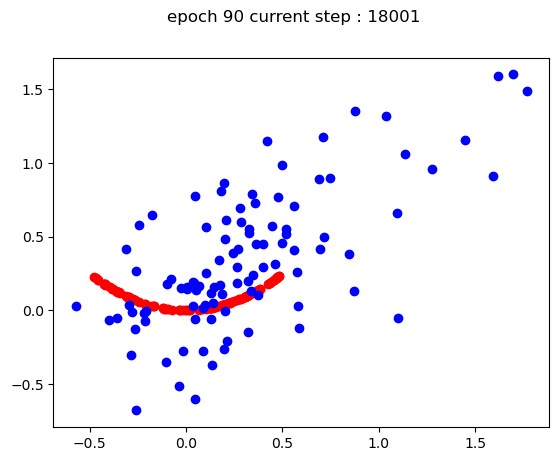

Step 18000: Generator loss: 25.303247104406296, discriminator loss: 18.679372000753887
Memory usage (RSS): 359.02734375 MB
Step 18500: Generator loss: 26.00391781520833, discriminator loss: 19.221409763753385
Memory usage (RSS): 359.16015625 MB
Step 19000: Generator loss: 26.70403501772872, discriminator loss: 19.76512882965798
Memory usage (RSS): 359.16015625 MB
Step 19500: Generator loss: 27.403843037724453, discriminator loss: 20.3101729622483
Memory usage (RSS): 359.16015625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch100.png


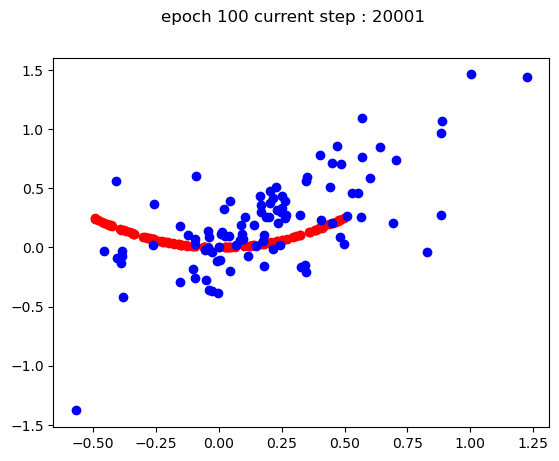

Step 20000: Generator loss: 28.103315977454173, discriminator loss: 20.856718375980822
Memory usage (RSS): 359.20703125 MB
Step 20500: Generator loss: 28.802814631223658, discriminator loss: 21.40436289352178
Memory usage (RSS): 359.3671875 MB
Step 21000: Generator loss: 29.502243358492816, discriminator loss: 21.95273353809116
Memory usage (RSS): 359.3671875 MB
Step 21500: Generator loss: 30.202067779064134, discriminator loss: 22.501879058182265
Memory usage (RSS): 359.3671875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch110.png


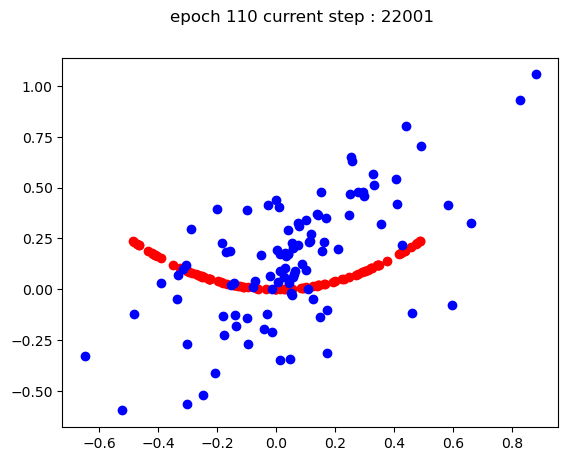

Step 22000: Generator loss: 30.902119625091522, discriminator loss: 23.051873110115515
Memory usage (RSS): 360.95703125 MB
Step 22500: Generator loss: 31.60251208293438, discriminator loss: 23.602721035182455
Memory usage (RSS): 361.17578125 MB
Step 23000: Generator loss: 32.303206319093725, discriminator loss: 24.154321378290614
Memory usage (RSS): 361.17578125 MB
Step 23500: Generator loss: 33.00434707546242, discriminator loss: 24.706664637744367
Memory usage (RSS): 361.17578125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch120.png


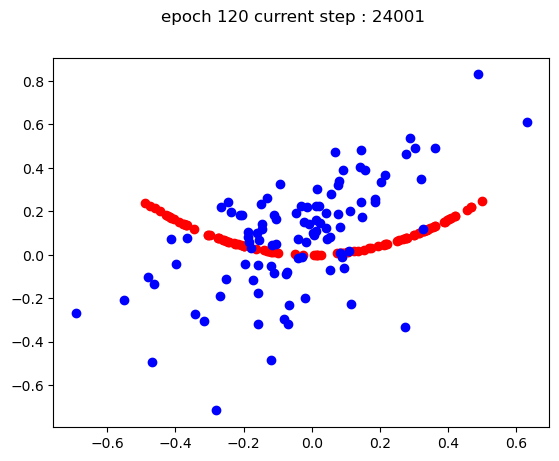

Step 24000: Generator loss: 33.70608591353901, discriminator loss: 25.260201675951397
Memory usage (RSS): 356.90625 MB
Step 24500: Generator loss: 34.407840423107395, discriminator loss: 25.814777817666503
Memory usage (RSS): 357.01171875 MB
Step 25000: Generator loss: 35.109973032355605, discriminator loss: 26.370655295908442
Memory usage (RSS): 357.0234375 MB
Step 25500: Generator loss: 35.81224750721493, discriminator loss: 26.927947161972522
Memory usage (RSS): 357.0234375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch130.png


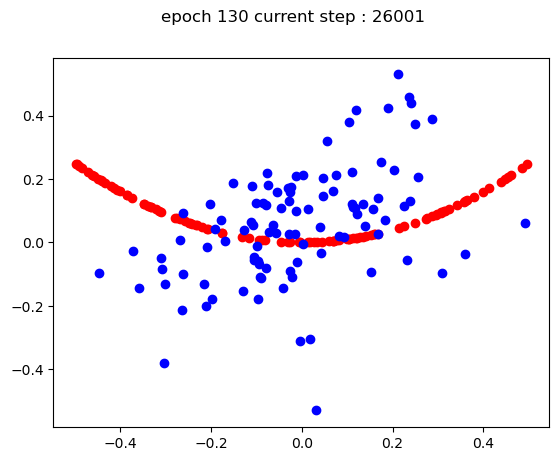

Step 26000: Generator loss: 36.51470136082203, discriminator loss: 27.48684853976965
Memory usage (RSS): 357.0234375 MB
Step 26500: Generator loss: 37.217103471994726, discriminator loss: 28.047335939109335
Memory usage (RSS): 357.0234375 MB
Step 27000: Generator loss: 37.9196036080125, discriminator loss: 28.60967763060334
Memory usage (RSS): 357.0234375 MB
Step 27500: Generator loss: 38.62202810013326, discriminator loss: 29.173893497169075
Memory usage (RSS): 357.0234375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch140.png


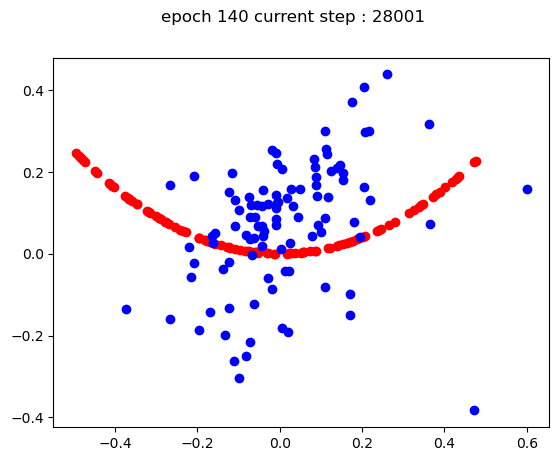

Step 28000: Generator loss: 39.32428654623063, discriminator loss: 29.73995101922757
Memory usage (RSS): 357.0234375 MB
Step 28500: Generator loss: 40.026515027284866, discriminator loss: 30.3080025280119
Memory usage (RSS): 357.0234375 MB
Step 29000: Generator loss: 40.72858174169092, discriminator loss: 30.878118889391494
Memory usage (RSS): 357.0234375 MB
Step 29500: Generator loss: 41.43048789870765, discriminator loss: 31.450315663039778
Memory usage (RSS): 357.0234375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch150.png


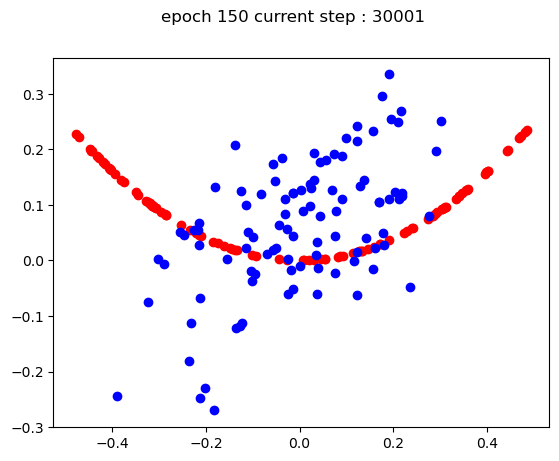

Step 30000: Generator loss: 42.13225780570538, discriminator loss: 32.02459464806329
Memory usage (RSS): 357.8125 MB
Step 30500: Generator loss: 42.833819082379584, discriminator loss: 32.60108656746163
Memory usage (RSS): 357.8125 MB
Step 31000: Generator loss: 43.535126452088655, discriminator loss: 33.179764137923904
Memory usage (RSS): 357.8125 MB
Step 31500: Generator loss: 44.236182260752045, discriminator loss: 33.760693871915485
Memory usage (RSS): 357.8125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch160.png


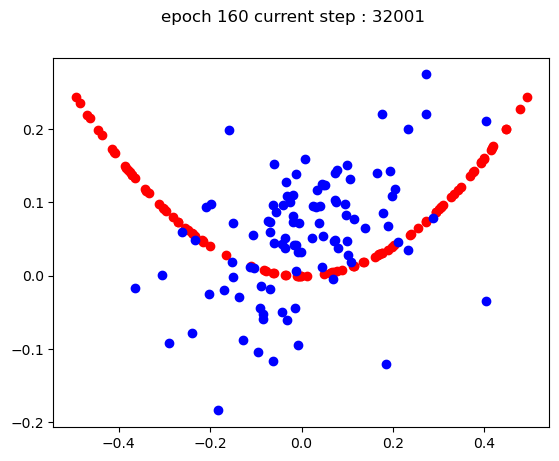

Step 32000: Generator loss: 44.93699302649532, discriminator loss: 34.34395669847735
Memory usage (RSS): 357.8203125 MB
Step 32500: Generator loss: 45.63754399669201, discriminator loss: 34.92960622483502
Memory usage (RSS): 357.8203125 MB
Step 33000: Generator loss: 46.337801859379134, discriminator loss: 35.51768443137416
Memory usage (RSS): 357.8203125 MB
Step 33500: Generator loss: 47.03775362181695, discriminator loss: 36.108145919263386
Memory usage (RSS): 357.94921875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch170.png


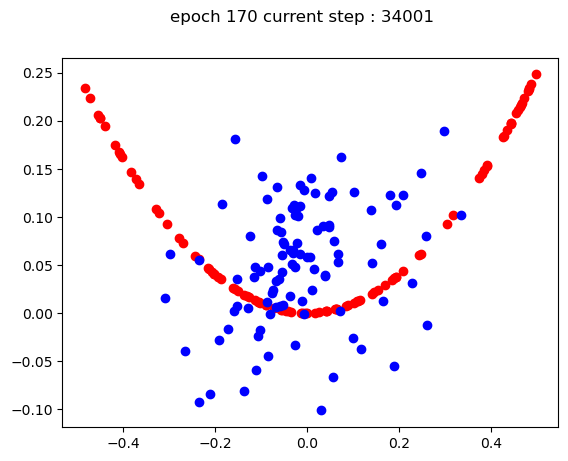

Step 34000: Generator loss: 47.73738483893904, discriminator loss: 36.701012953341014
Memory usage (RSS): 359.625 MB
Step 34500: Generator loss: 48.43667066192659, discriminator loss: 37.296345039784896
Memory usage (RSS): 359.625 MB
Step 35000: Generator loss: 49.13561230969465, discriminator loss: 37.8942074232697
Memory usage (RSS): 359.625 MB
Step 35500: Generator loss: 49.834206644297105, discriminator loss: 38.49464126604794
Memory usage (RSS): 359.625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch180.png


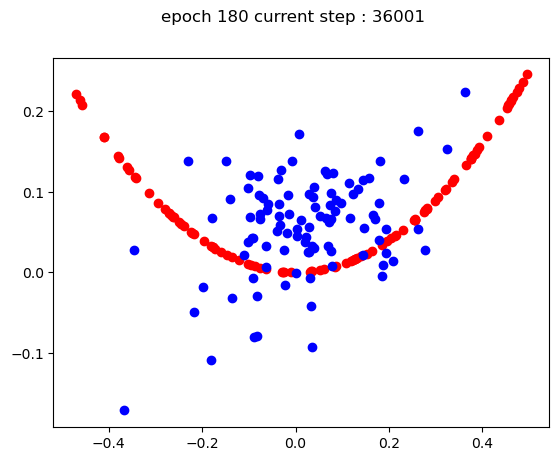

Step 36000: Generator loss: 50.53244187998822, discriminator loss: 39.09757781773802
Memory usage (RSS): 359.625 MB
Step 36500: Generator loss: 51.23031642949632, discriminator loss: 39.703084138453036
Memory usage (RSS): 359.7578125 MB
Step 37000: Generator loss: 51.927805629730706, discriminator loss: 40.31113796490436
Memory usage (RSS): 359.7578125 MB
Step 37500: Generator loss: 52.624985384703166, discriminator loss: 40.921697476565896
Memory usage (RSS): 359.78125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch190.png


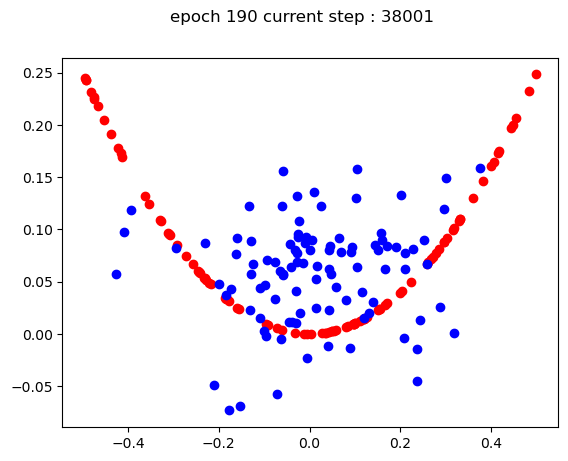

Step 38000: Generator loss: 53.32183277261309, discriminator loss: 41.53470736604935
Memory usage (RSS): 360.734375 MB
Step 38500: Generator loss: 54.01836844360883, discriminator loss: 42.150135081350825
Memory usage (RSS): 360.85546875 MB
Step 39000: Generator loss: 54.7146256102329, discriminator loss: 42.76793932324652
Memory usage (RSS): 360.85546875 MB
Step 39500: Generator loss: 55.41062484979683, discriminator loss: 43.38807117205865
Memory usage (RSS): 360.85546875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch200.png


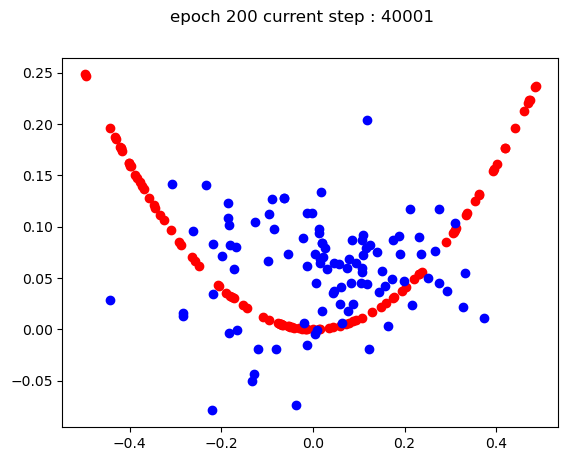

Step 40000: Generator loss: 56.106346403241695, discriminator loss: 44.01047606724508
Memory usage (RSS): 360.859375 MB
Step 40500: Generator loss: 56.801840527535006, discriminator loss: 44.63514829427001
Memory usage (RSS): 361.05859375 MB
Step 41000: Generator loss: 57.49712325143862, discriminator loss: 45.262037728726796
Memory usage (RSS): 361.05859375 MB
Step 41500: Generator loss: 58.19220428133063, discriminator loss: 45.8910923065543
Memory usage (RSS): 361.05859375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch210.png


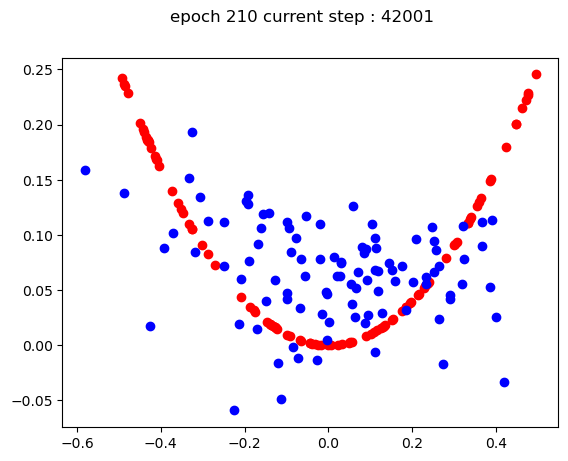

Step 42000: Generator loss: 58.88710066294722, discriminator loss: 46.52229752045869
Memory usage (RSS): 362.20703125 MB
Step 42500: Generator loss: 59.58180323445855, discriminator loss: 47.15555452710394
Memory usage (RSS): 362.390625 MB
Step 43000: Generator loss: 60.276344774485175, discriminator loss: 47.79080126243834
Memory usage (RSS): 362.390625 MB
Step 43500: Generator loss: 60.97073905444202, discriminator loss: 48.42799427896744
Memory usage (RSS): 362.390625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch220.png


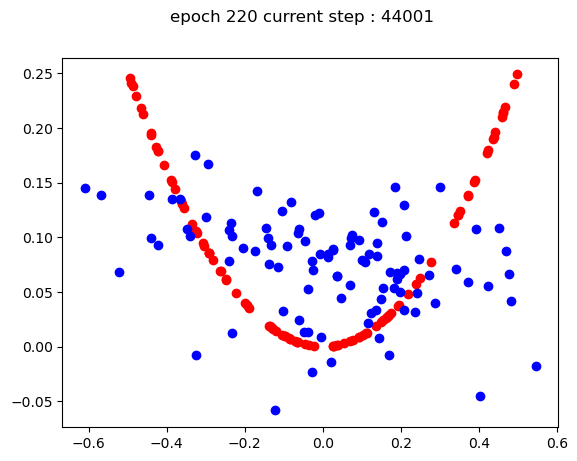

Step 44000: Generator loss: 61.664992331505275, discriminator loss: 49.06707333940278
Memory usage (RSS): 362.390625 MB
Step 44500: Generator loss: 62.35913352346467, discriminator loss: 49.70798665803683
Memory usage (RSS): 362.5390625 MB
Step 45000: Generator loss: 63.05315807974387, discriminator loss: 50.35071210044644
Memory usage (RSS): 362.5390625 MB
Step 45500: Generator loss: 63.74708194005532, discriminator loss: 50.99515636497756
Memory usage (RSS): 362.5390625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch230.png


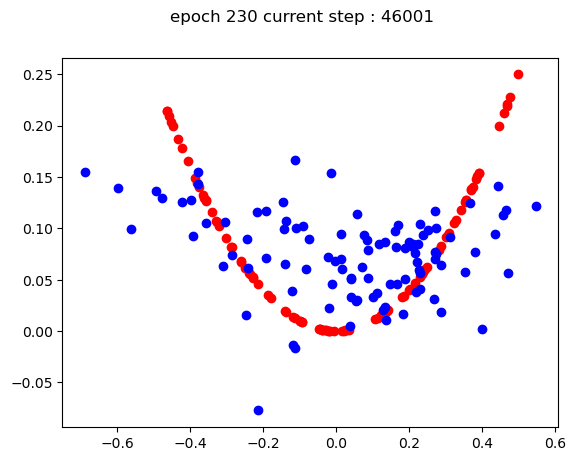

Step 46000: Generator loss: 64.44090408313315, discriminator loss: 51.64123918801567
Memory usage (RSS): 364.0 MB
Step 46500: Generator loss: 65.13463590610074, discriminator loss: 52.28890597659364
Memory usage (RSS): 364.00390625 MB
Step 47000: Generator loss: 65.8282977889782, discriminator loss: 52.93812235611695
Memory usage (RSS): 364.00390625 MB
Step 47500: Generator loss: 66.52188274729313, discriminator loss: 53.588821882307705
Memory usage (RSS): 364.00390625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch240.png


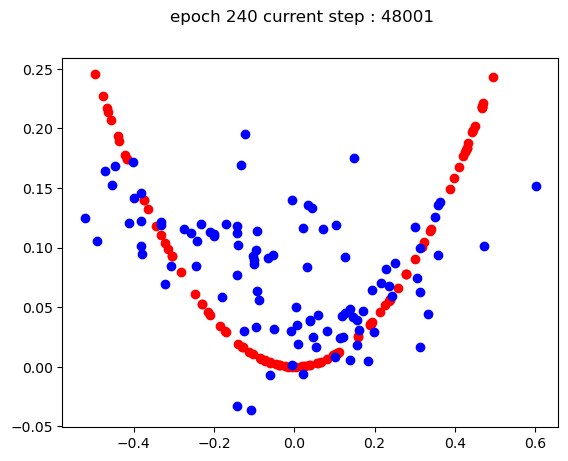

Step 48000: Generator loss: 67.21540916061471, discriminator loss: 54.24094399565471
Memory usage (RSS): 364.00390625 MB
Step 48500: Generator loss: 67.90888670444531, discriminator loss: 54.89444712549462
Memory usage (RSS): 364.1484375 MB
Step 49000: Generator loss: 68.60231307601983, discriminator loss: 55.549258401692036
Memory usage (RSS): 364.1484375 MB
Step 49500: Generator loss: 69.29569132423443, discriminator loss: 56.20531382387885
Memory usage (RSS): 364.30859375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch250.png


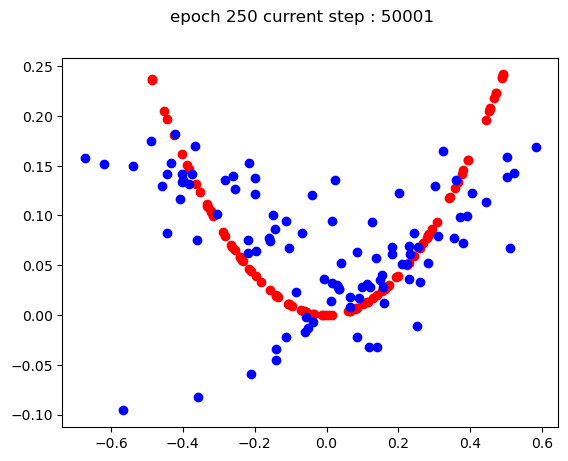

Step 50000: Generator loss: 69.98902575886288, discriminator loss: 56.86255115562685
Memory usage (RSS): 366.03515625 MB
Step 50500: Generator loss: 70.68232994580308, discriminator loss: 57.52094133752585
Memory usage (RSS): 366.03515625 MB
Step 51000: Generator loss: 71.37559630250976, discriminator loss: 58.180428407967106
Memory usage (RSS): 366.03515625 MB
Step 51500: Generator loss: 72.06883764982268, discriminator loss: 58.84096229320768
Memory usage (RSS): 366.03515625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch260.png


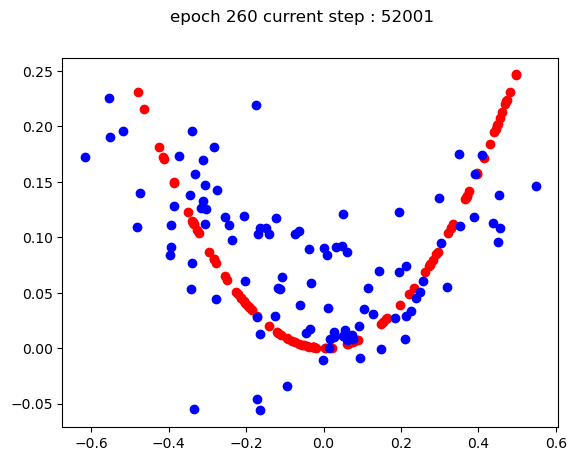

Step 52000: Generator loss: 72.76204752183006, discriminator loss: 59.502540262877986
Memory usage (RSS): 366.1015625 MB
Step 52500: Generator loss: 73.45523647379916, discriminator loss: 60.16513389462243
Memory usage (RSS): 366.1484375 MB
Step 53000: Generator loss: 74.14840810263188, discriminator loss: 60.82870207530264
Memory usage (RSS): 366.1484375 MB
Step 53500: Generator loss: 74.84155809891256, discriminator loss: 61.49319152766474
Memory usage (RSS): 366.1484375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch270.png


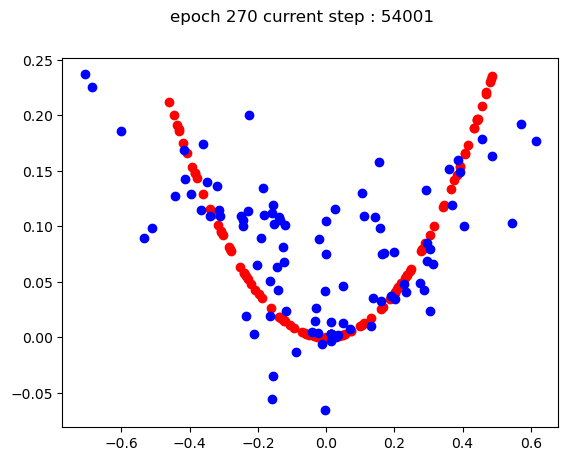

Step 54000: Generator loss: 75.53470729219956, discriminator loss: 62.158591336548426
Memory usage (RSS): 367.72265625 MB
Step 54500: Generator loss: 76.22784273159543, discriminator loss: 62.82490054982912
Memory usage (RSS): 367.8984375 MB
Step 55000: Generator loss: 76.92097260367903, discriminator loss: 63.49208828812853
Memory usage (RSS): 367.8984375 MB
Step 55500: Generator loss: 77.61409250867402, discriminator loss: 64.16007718485612
Memory usage (RSS): 367.8984375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch280.png


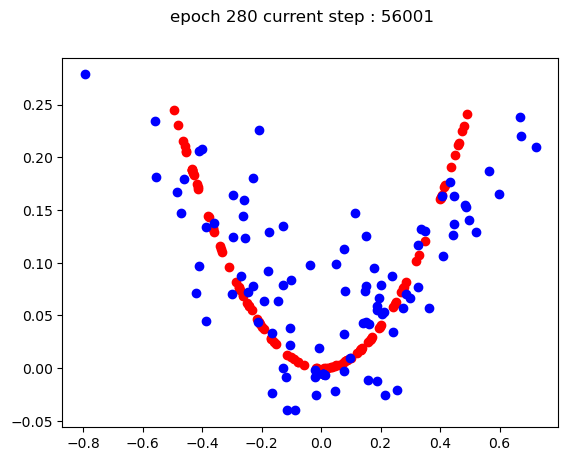

Step 56000: Generator loss: 78.30720590496108, discriminator loss: 64.82886318641918
Memory usage (RSS): 367.8984375 MB
Step 56500: Generator loss: 79.00031445992053, discriminator loss: 65.49840612977759
Memory usage (RSS): 367.99609375 MB
Step 57000: Generator loss: 79.69341506111692, discriminator loss: 66.16867794257415
Memory usage (RSS): 367.99609375 MB
Step 57500: Generator loss: 80.38651626885017, discriminator loss: 66.83962744599607
Memory usage (RSS): 367.99609375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch290.png


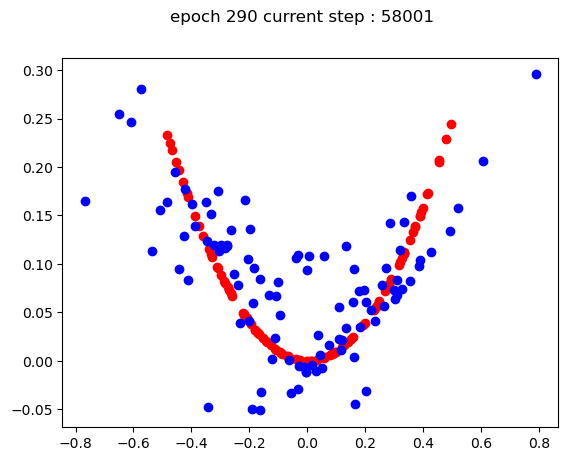

Step 58000: Generator loss: 81.0796100981244, discriminator loss: 67.5112255668047
Memory usage (RSS): 369.65625 MB
Step 58500: Generator loss: 81.77270109772759, discriminator loss: 68.18346653062116
Memory usage (RSS): 369.89453125 MB
Step 59000: Generator loss: 82.46579023337439, discriminator loss: 68.85630972713238
Memory usage (RSS): 369.89453125 MB
Step 59500: Generator loss: 83.15887820053189, discriminator loss: 69.52971302300692
Memory usage (RSS): 369.89453125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch300.png


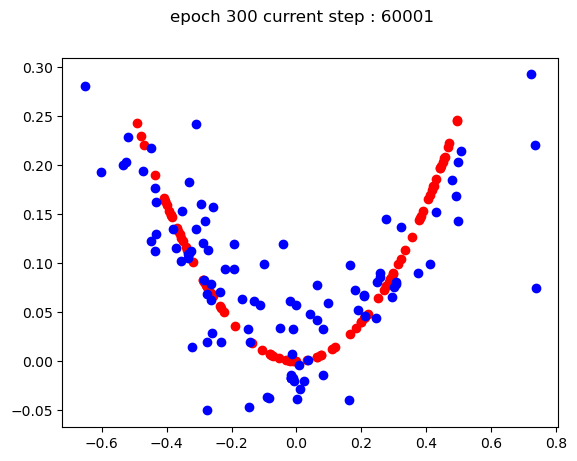

Step 60000: Generator loss: 83.85196436572164, discriminator loss: 70.20367453986401
Memory usage (RSS): 369.96875 MB
Step 60500: Generator loss: 84.54504980135057, discriminator loss: 70.87814240986098
Memory usage (RSS): 369.96875 MB
Step 61000: Generator loss: 85.23814242279626, discriminator loss: 71.5531138997674
Memory usage (RSS): 369.96875 MB
Step 61500: Generator loss: 85.9312304847251, discriminator loss: 72.22857824450728
Memory usage (RSS): 369.96875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch310.png


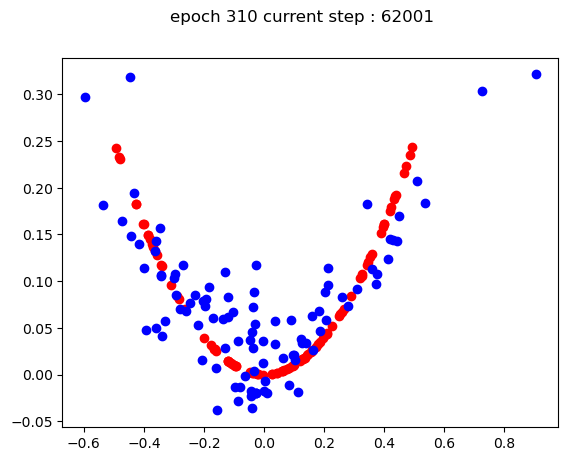

Step 62000: Generator loss: 86.6243190025101, discriminator loss: 72.90448948401209
Memory usage (RSS): 371.9140625 MB
Step 62500: Generator loss: 87.31740167474858, discriminator loss: 73.58081329458948
Memory usage (RSS): 372.14453125 MB
Step 63000: Generator loss: 88.01048316502684, discriminator loss: 74.2575074496866
Memory usage (RSS): 372.14453125 MB
Step 63500: Generator loss: 88.70356393575783, discriminator loss: 74.93455319660922
Memory usage (RSS): 372.14453125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch320.png


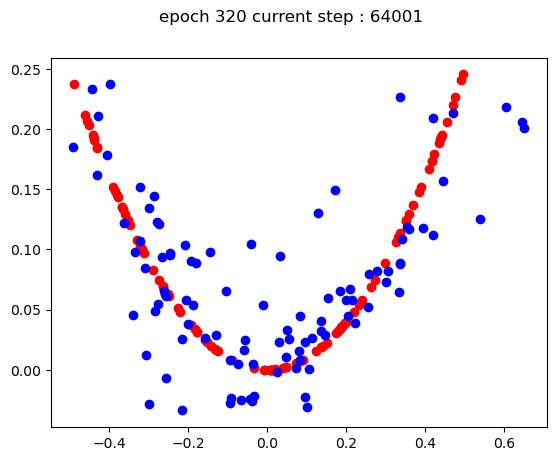

Step 64000: Generator loss: 89.39664489662769, discriminator loss: 75.61193725687282
Memory usage (RSS): 373.51953125 MB
Step 64500: Generator loss: 90.08972759366155, discriminator loss: 76.28966572433725
Memory usage (RSS): 373.51953125 MB
Step 65000: Generator loss: 90.7828054009689, discriminator loss: 76.96770134276166
Memory usage (RSS): 373.51953125 MB
Step 65500: Generator loss: 91.47588711238045, discriminator loss: 77.64603423601406
Memory usage (RSS): 373.51953125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch330.png


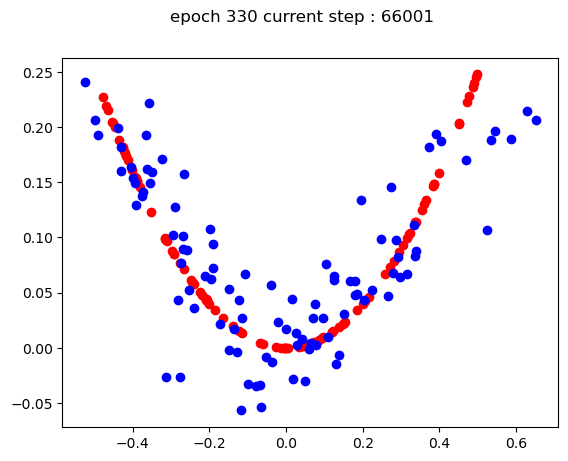

Step 66000: Generator loss: 92.16896646201734, discriminator loss: 78.32464009577065
Memory usage (RSS): 374.11328125 MB
Step 66500: Generator loss: 92.86204423225044, discriminator loss: 79.00350906878737
Memory usage (RSS): 374.11328125 MB
Step 67000: Generator loss: 93.55512286365145, discriminator loss: 79.68259726578036
Memory usage (RSS): 374.11328125 MB
Step 67500: Generator loss: 94.24820168590652, discriminator loss: 80.36192272609513
Memory usage (RSS): 374.11328125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch340.png


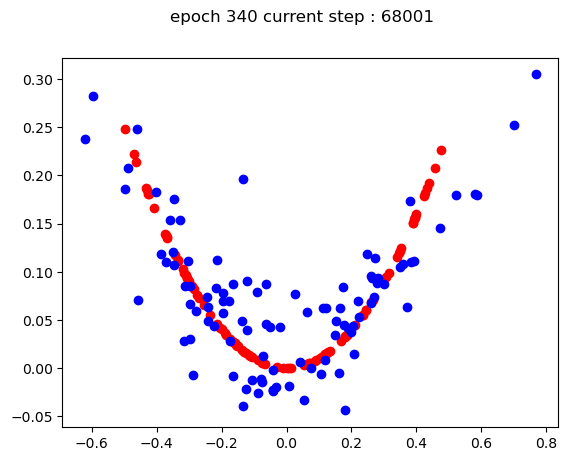

Step 68000: Generator loss: 94.9412801283608, discriminator loss: 81.04147516065878
Memory usage (RSS): 375.546875 MB
Step 68500: Generator loss: 95.63435808301068, discriminator loss: 81.7212273413545
Memory usage (RSS): 375.546875 MB
Step 69000: Generator loss: 96.32743817639444, discriminator loss: 82.40119138342192
Memory usage (RSS): 375.546875 MB
Step 69500: Generator loss: 97.02051538539021, discriminator loss: 83.08131501930994
Memory usage (RSS): 375.55078125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch350.png


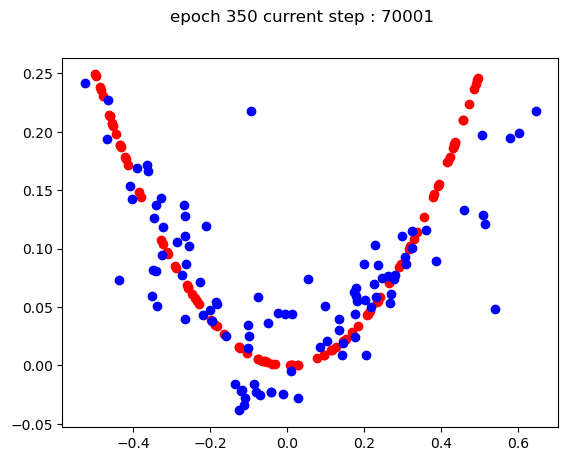

Step 70000: Generator loss: 97.71359189295855, discriminator loss: 83.76157449024956
Memory usage (RSS): 375.9765625 MB
Step 70500: Generator loss: 98.4066681672342, discriminator loss: 84.44197671586316
Memory usage (RSS): 375.9765625 MB
Step 71000: Generator loss: 99.09974455320908, discriminator loss: 85.12249535065939
Memory usage (RSS): 375.9765625 MB
Step 71500: Generator loss: 99.79282392895308, discriminator loss: 85.80314747268007
Memory usage (RSS): 375.9765625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch360.png


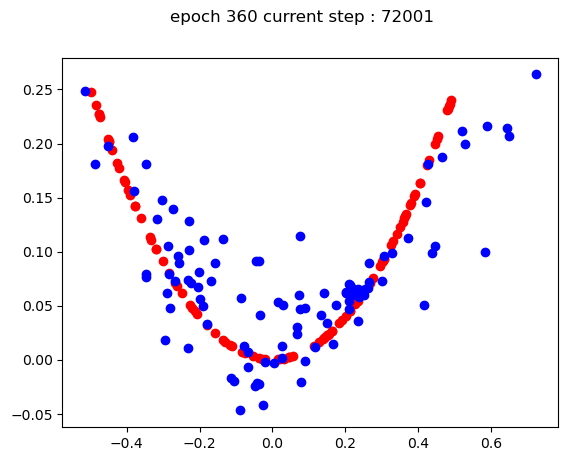

Step 72000: Generator loss: 100.48590348887508, discriminator loss: 86.48393803185269
Memory usage (RSS): 377.140625 MB
Step 72500: Generator loss: 101.17897957146228, discriminator loss: 87.16482914394169
Memory usage (RSS): 377.359375 MB
Step 73000: Generator loss: 101.87205924034193, discriminator loss: 87.84581203526297
Memory usage (RSS): 377.359375 MB
Step 73500: Generator loss: 102.56513706278875, discriminator loss: 88.52688444834988
Memory usage (RSS): 377.359375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch370.png


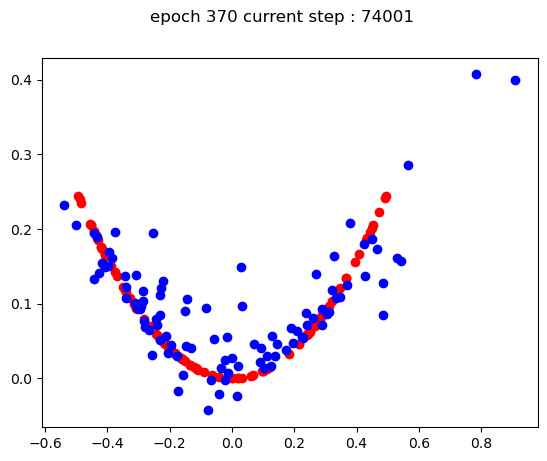

Step 74000: Generator loss: 103.25821662950591, discriminator loss: 89.20804662078655
Memory usage (RSS): 378.41015625 MB
Step 74500: Generator loss: 103.9512988506563, discriminator loss: 89.88929665595299
Memory usage (RSS): 378.5859375 MB
Step 75000: Generator loss: 104.64437847173288, discriminator loss: 90.57061961680665
Memory usage (RSS): 378.5859375 MB
Step 75500: Generator loss: 105.3374586590536, discriminator loss: 91.25200967007899
Memory usage (RSS): 378.5859375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch380.png


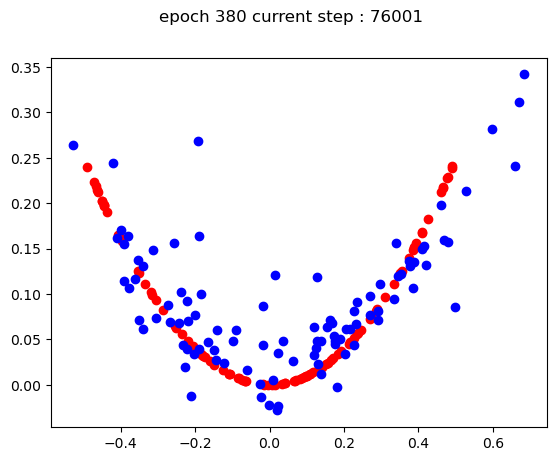

Step 76000: Generator loss: 106.03054016959747, discriminator loss: 91.93347306257505
Memory usage (RSS): 379.16015625 MB
Step 76500: Generator loss: 106.72362296080661, discriminator loss: 92.61501133948592
Memory usage (RSS): 379.16015625 MB
Step 77000: Generator loss: 107.41670487129758, discriminator loss: 93.29660874146255
Memory usage (RSS): 379.16015625 MB
Step 77500: Generator loss: 108.10978919100837, discriminator loss: 93.9782638751866
Memory usage (RSS): 379.16015625 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch390.png


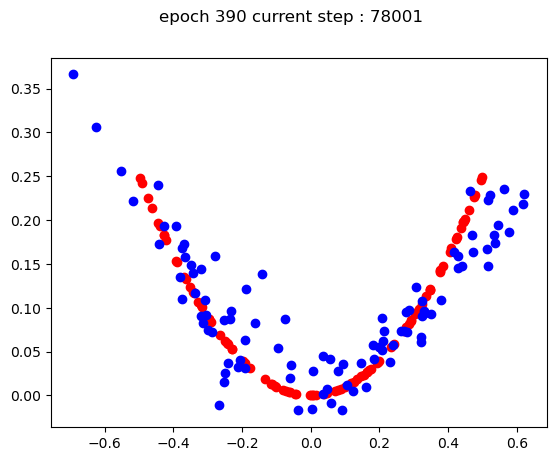

Step 78000: Generator loss: 108.80287270581799, discriminator loss: 94.65997997242226
Memory usage (RSS): 380.19140625 MB
Step 78500: Generator loss: 109.49595345664086, discriminator loss: 95.34174531012788
Memory usage (RSS): 380.3984375 MB
Step 79000: Generator loss: 110.18903738522596, discriminator loss: 96.02355078643586
Memory usage (RSS): 380.3984375 MB
Step 79500: Generator loss: 110.88212329518878, discriminator loss: 96.70541432386644
Memory usage (RSS): 380.3984375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch400.png


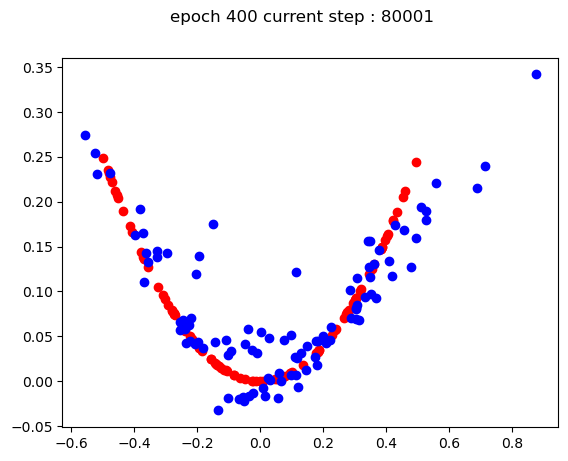

Step 80000: Generator loss: 111.57521054816331, discriminator loss: 97.3873514482381
Memory usage (RSS): 381.12109375 MB
Step 80500: Generator loss: 112.26829941511237, discriminator loss: 98.06936029595168
Memory usage (RSS): 381.12109375 MB
Step 81000: Generator loss: 112.9613857141741, discriminator loss: 98.75141333585998
Memory usage (RSS): 381.12109375 MB
Step 81500: Generator loss: 113.65447252285556, discriminator loss: 99.43352121681
Memory usage (RSS): 381.12109375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch410.png


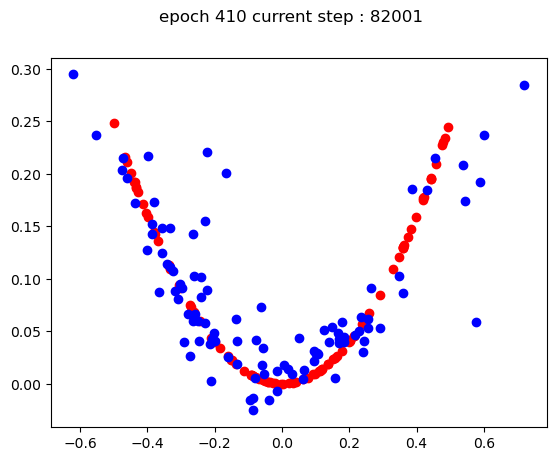

Step 82000: Generator loss: 114.34756005477968, discriminator loss: 100.11566683393758
Memory usage (RSS): 382.3203125 MB
Step 82500: Generator loss: 115.04064877641255, discriminator loss: 100.7978694428806
Memory usage (RSS): 382.3203125 MB
Step 83000: Generator loss: 115.73374198234139, discriminator loss: 101.48013656848732
Memory usage (RSS): 382.3203125 MB
Step 83500: Generator loss: 116.42683655858094, discriminator loss: 102.16249223488622
Memory usage (RSS): 382.3203125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch420.png


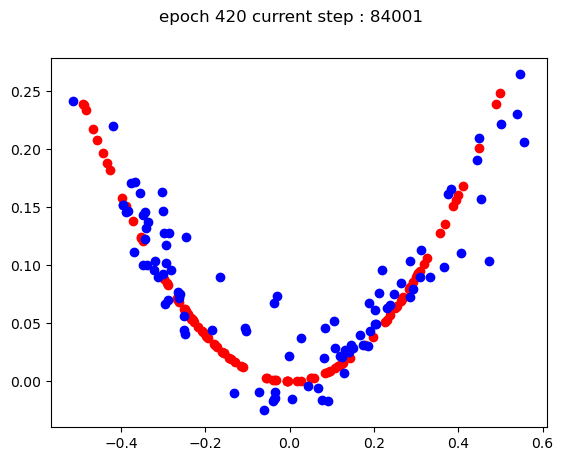

Step 84000: Generator loss: 117.11992882490205, discriminator loss: 102.84491948300659
Memory usage (RSS): 382.76171875 MB
Step 84500: Generator loss: 117.81302292788057, discriminator loss: 103.52740975183296
Memory usage (RSS): 382.828125 MB
Step 85000: Generator loss: 118.50611588180095, discriminator loss: 104.20996627849388
Memory usage (RSS): 382.828125 MB
Step 85500: Generator loss: 119.19921071302912, discriminator loss: 104.89257059246346
Memory usage (RSS): 382.828125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch430.png


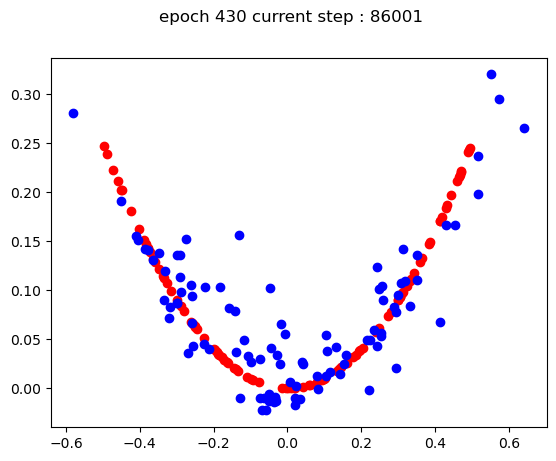

Step 86000: Generator loss: 119.8923083266021, discriminator loss: 105.57525932484913
Memory usage (RSS): 383.3671875 MB
Step 86500: Generator loss: 120.5854094352724, discriminator loss: 106.25804489558986
Memory usage (RSS): 383.3671875 MB
Step 87000: Generator loss: 121.2785116093161, discriminator loss: 106.94092640298658
Memory usage (RSS): 383.3671875 MB
Step 87500: Generator loss: 121.97160962867756, discriminator loss: 107.62389064997485
Memory usage (RSS): 383.3671875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch440.png


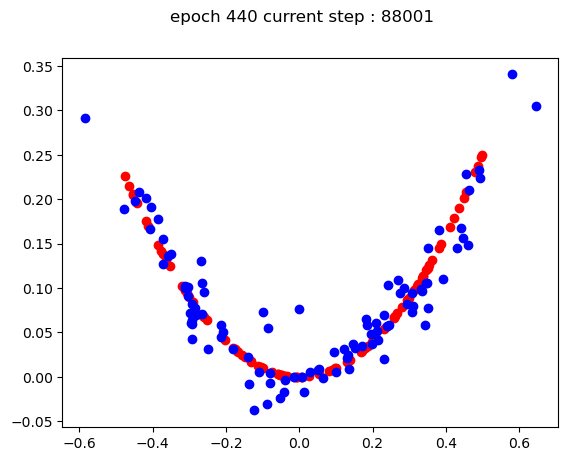

Step 88000: Generator loss: 122.66471085822594, discriminator loss: 108.30692259579939
Memory usage (RSS): 384.69140625 MB
Step 88500: Generator loss: 123.35781445872786, discriminator loss: 108.99004222434803
Memory usage (RSS): 384.796875 MB
Step 89000: Generator loss: 124.05092031192777, discriminator loss: 109.67326471310896
Memory usage (RSS): 384.796875 MB
Step 89500: Generator loss: 124.74402426874641, discriminator loss: 110.3565813559893
Memory usage (RSS): 384.796875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch450.png


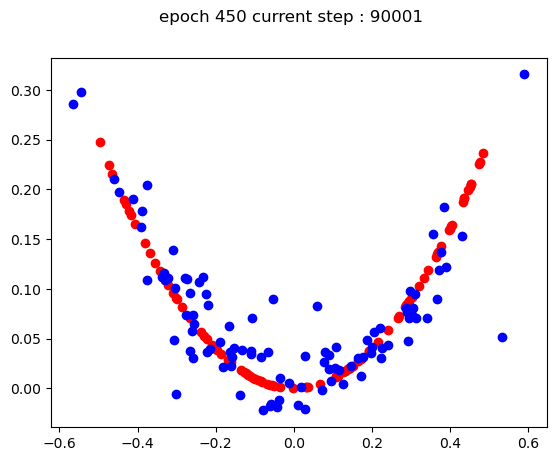

Step 90000: Generator loss: 125.43712910687917, discriminator loss: 111.039974640787
Memory usage (RSS): 385.2109375 MB
Step 90500: Generator loss: 126.1302339533568, discriminator loss: 111.72344612771303
Memory usage (RSS): 385.2109375 MB
Step 91000: Generator loss: 126.82334198725216, discriminator loss: 112.4070143278243
Memory usage (RSS): 385.2109375 MB
Step 91500: Generator loss: 127.51644755852206, discriminator loss: 113.09065669435293
Memory usage (RSS): 385.2109375 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch460.png


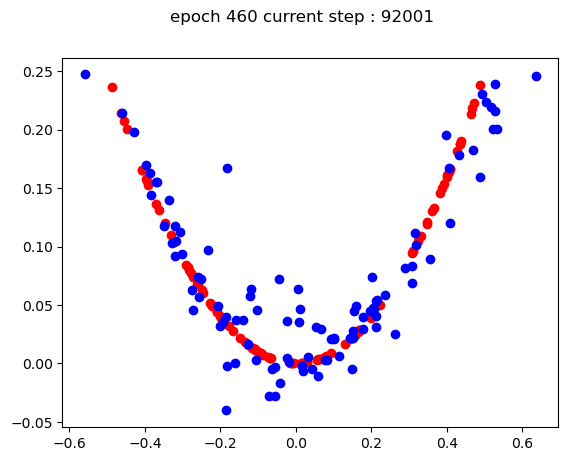

Step 92000: Generator loss: 128.20955457639684, discriminator loss: 113.77436004084392
Memory usage (RSS): 386.50390625 MB
Step 92500: Generator loss: 128.9026625227929, discriminator loss: 114.45813377064508
Memory usage (RSS): 386.6328125 MB
Step 93000: Generator loss: 129.59577222931412, discriminator loss: 115.1419990491275
Memory usage (RSS): 386.6328125 MB
Step 93500: Generator loss: 130.28888445448942, discriminator loss: 115.82595837158003
Memory usage (RSS): 386.6328125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch470.png


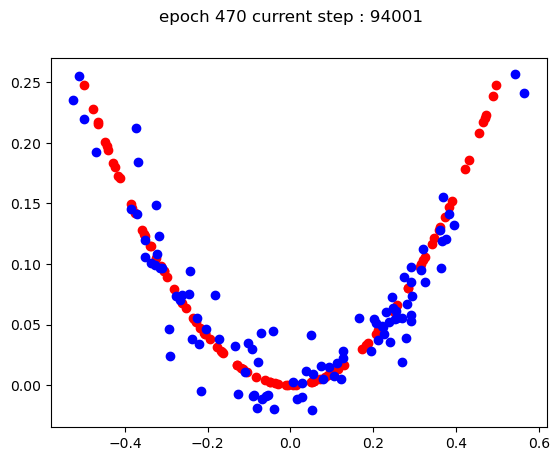

Step 94000: Generator loss: 130.98199685990846, discriminator loss: 116.51001807850609
Memory usage (RSS): 387.7578125 MB
Step 94500: Generator loss: 131.67510809361966, discriminator loss: 117.19416624242089
Memory usage (RSS): 387.7578125 MB
Step 95000: Generator loss: 132.3682208962445, discriminator loss: 117.87838640791196
Memory usage (RSS): 387.7578125 MB
Step 95500: Generator loss: 133.06133274531433, discriminator loss: 118.56268811696799
Memory usage (RSS): 387.7578125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch480.png


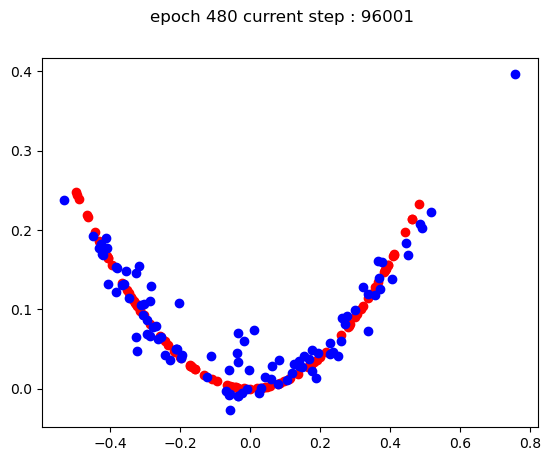

Step 96000: Generator loss: 133.75444782424057, discriminator loss: 119.24706247001913
Memory usage (RSS): 388.25390625 MB
Step 96500: Generator loss: 134.44756331849163, discriminator loss: 119.93152540880476
Memory usage (RSS): 388.36328125 MB
Step 97000: Generator loss: 135.14068087267918, discriminator loss: 120.61609564954075
Memory usage (RSS): 388.36328125 MB
Step 97500: Generator loss: 135.8337985043529, discriminator loss: 121.30075855058462
Memory usage (RSS): 388.36328125 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch490.png


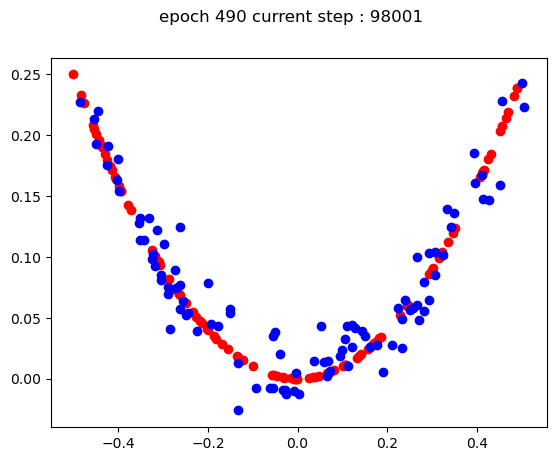

Step 98000: Generator loss: 136.52691640973129, discriminator loss: 121.9855075588824
Memory usage (RSS): 386.3515625 MB
Step 98500: Generator loss: 137.22003466284315, discriminator loss: 122.6703304551246
Memory usage (RSS): 386.3515625 MB
Step 99000: Generator loss: 137.91315337371884, discriminator loss: 123.35522501105085
Memory usage (RSS): 386.3671875 MB
Step 99500: Generator loss: 138.60627312552975, discriminator loss: 124.04020549660949
Memory usage (RSS): 386.3671875 MB
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/testConditionalGAN_pytorch_1.out/img/generated_plot_epoch500.png


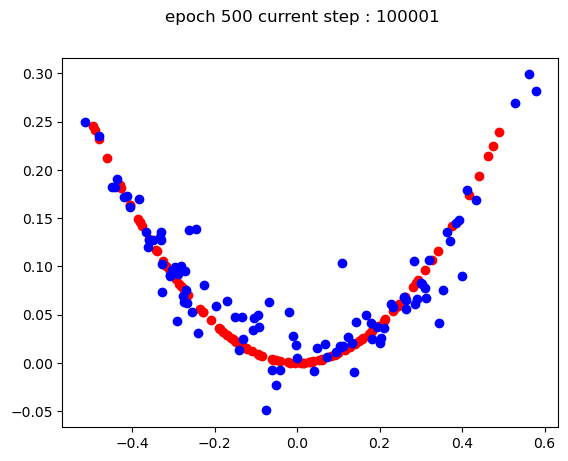

finished
CPU times: user 7h 4min 57s, sys: 25min 31s, total: 7h 30min 29s
Wall time: 5min 38s


In [13]:
%%time

# reset state every time we run
currentStep = 0
meanGeneratorLoss = 0
meanDiscriminatorLoss = 0
testGenerator = True # Whether the generator should be tested
genLoss = False
error = False


for epoch in range(nEpochs):
    # print(f'epoch: {epoch}')    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        realSamples, realLabels = generateRealSamples( currentBatchSize )
        
        #
        # Update discriminator 
        #
        
        # Zero out the gradients before backpropagation
        discriminatorOptimizer.zero_grad()
        
        # Calculate discriminator loss
        discLoss = getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
                                  currentBatchSize, zDim, device)
        
        # Update gradients
        discLoss.backward(retain_graph=True)
        
        # Update optimizer
        discriminatorOptimizer.step()

        #
        # update generator
        #

        # For testing purposes, to keep track of the generator weights
        if testGenerator:
            # our last layer is a linear label not a list of layers
            #oldGeneratorWeights = generator.model[0][0].weight.detach().clone()
            oldGeneratorWeights = generator.model[0].weight.detach().clone()

        generatorOptimizer.zero_grad()
        generatorLoss = getGeneratorLoss(generator, discriminator, criterion, 
                                         currentBatchSize, zDim, device)
        generatorLoss.backward(retain_graph=True)
        generatorOptimizer.step()

        #
        # For testing purposes, to check that your code changes the generator weights
        #
        if testGenerator:
            try:
                # assert lr > 0.0000002 or (gen.gen[0][0].weight.grad.abs().max() < 0.0005 and epoch == 0)
                xxx = generator.model[0].weight.grad.abs().max()
                # print(f'AEDWIP xxx : {xxx}')
                errMsg = f'assertion failed condition : {xxx}'
                assert (lr > 0.0000002 or xxx < 0.0005 and epoch == 0), errMsg

                
                #assert torch.any(gen.gen[0][0].weight.detach().clone() != old_generator_weights)
                yyy = generator.model[0].weight.detach().clone()
                # print(f'aedwip yyy : {yyy}')
                # print(f'aedwip old : {oldGeneratorWeights}')
                errMsg = f'weights not equal old'
                assert torch.any(yyy != oldGeneratorWeights), errMsg
            except Exception as e:
                print(f'aedwip e:\n{e}')
                error = True
                print("Runtime tests have failed")

        # Keep track of the average discriminator loss
        meanDiscriminatorLoss += discLoss.item() / displayStep

        # Keep track of the average generator loss
        meanGeneratorLoss += generatorLoss.item() / displayStep

        ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            print(f"Step {currentStep}: Generator loss: {meanDiscriminatorLoss}, discriminator loss: {meanGeneratorLoss}")

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #display plot
            
            mean_generator_loss = 0
            mean_discriminator_loss = 0
            
        currentStep += 1

        
        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1} current step : {currentStep + 1}"
            summarizePerformance(generator, zDim, imgOut, title)

print(f'finished')